# Alignment Integration

Temporal alignment between source speech timing and target-language TTS audio.
This is the hard problem: a 3-second English phrase might take 5 seconds in Spanish.

Covers segment metrics, fallback policy, and global timeline optimization.

## Setup

In [1]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

IMAGES_DIR = Path.cwd() / "images"
IMAGES_DIR.mkdir(exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"IMAGES_DIR:   {IMAGES_DIR}")

PROJECT_ROOT: /home/joshu/CS4613/foreign-whispers
IMAGES_DIR:   /home/joshu/CS4613/foreign-whispers/notebooks/alignment_integration/images


## Load Cached Transcripts

Load from `pipeline_data` (no API call needed).

In [2]:
en_dir = PROJECT_ROOT / "pipeline_data" / "api" / "transcriptions" / "whisper"
es_dir = PROJECT_ROOT / "pipeline_data" / "api" / "translations" / "argos"

en_files = sorted(en_dir.glob("*.json"))
es_files = sorted(es_dir.glob("*.json"))

assert en_files, f"No EN transcripts found in {en_dir}"
assert es_files, f"No ES translations found in {es_dir}"

en_path = en_files[0]
es_path = es_files[0]

with open(en_path) as f:
    en_transcript = json.load(f)
with open(es_path) as f:
    es_transcript = json.load(f)

print(f"EN transcript: {en_path.name}  ({len(en_transcript.get('segments', []))} segments)")
print(f"ES transcript: {es_path.name}  ({len(es_transcript.get('segments', []))} segments)")

EN transcript: Strait of Hormuz disruption threatens to shake global economy.json  (98 segments)
ES transcript: Strait of Hormuz disruption threatens to shake global economy.json  (170 segments)


## Segment Timing Metrics

Compute predicted stretch factor and overflow for each segment.

The syllable-based duration heuristic estimates TTS output length at ~4.5 syllables/second
for Romance languages (~15 chars/s). For each segment we compare the predicted TTS duration
against the source-language time window to get `predicted_stretch` (1.0 = perfect fit,
1.3 = 30% too long).

**Notice what happens:** many segments have stretch factors well above 1.0. The translator
doesn't know about the timing budget — it just rewrites text without considering how long
it takes to speak. This is the core problem you'll address in the tasks below.

In [3]:
from foreign_whispers import (
    AlignAction, AlignedSegment, SegmentMetrics,
    compute_segment_metrics, decide_action,
)

all_metrics = compute_segment_metrics(en_transcript, es_transcript)
bad = [m for m in all_metrics if m.predicted_stretch > 1.5]

print(f"Total segments : {len(all_metrics)}")
print(f"Stretch > 1.5x : {len(bad)}  ({100*len(bad)/max(len(all_metrics),1):.0f}%)")
print("\nWorst 5:")
for m in sorted(bad, key=lambda x: -x.predicted_stretch)[:5]:
    print(f"  seg {m.index:3d}  stretch={m.predicted_stretch:.2f}x  overflow={m.overflow_s:.1f}s")
    print(f"    EN: {m.source_text[:55]}")
    print(f"    ES: {m.translated_text[:55]}")

Total segments : 98
Stretch > 1.5x : 9  (9%)

Worst 5:
  seg  95  stretch=2.42x  overflow=1.4s
    EN: Yes.
    ES: > Esto es un verdadero golpe de estómago para su
  seg  89  stretch=2.33x  overflow=1.3s
    EN: Look, yes.
    ES: > Putin, ninguna pregunta, se está beneficiando
  seg  17  stretch=2.15x  overflow=1.2s
    EN: the strait.
    ES: aceite y una cantidad significativa de natural
  seg  72  stretch=1.97x  overflow=1.0s
    EN: big stockpiles.
    ES: se ha levantado el precio total de crudo
  seg  87  stretch=1.88x  overflow=0.9s
    EN: recession.
    ES: Hormuz, lo he visto decir que Rusia es


## Visualize Stretch Distribution

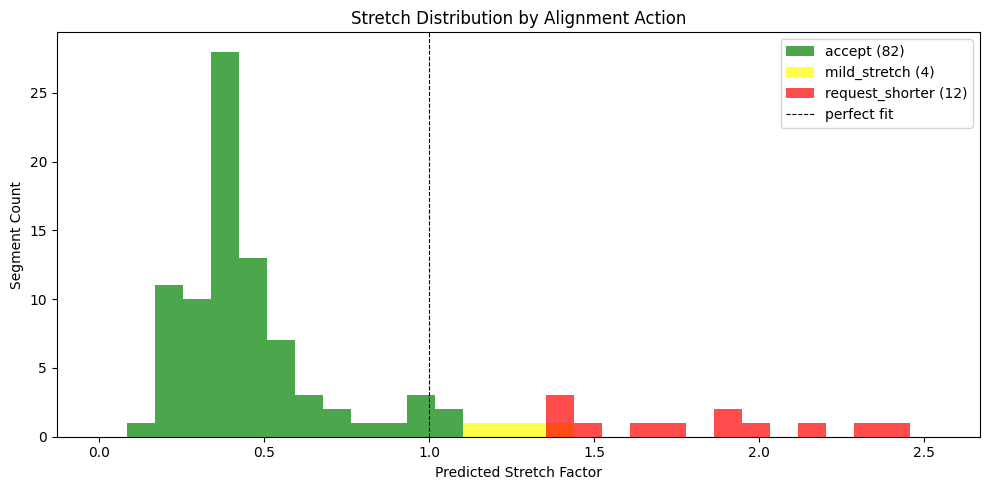

Saved to /home/joshu/CS4613/foreign-whispers/notebooks/alignment_integration/images/stretch_distribution.png


In [4]:
import matplotlib.pyplot as plt
import numpy as np

stretches = [m.predicted_stretch for m in all_metrics]
actions = [decide_action(m) for m in all_metrics]

color_map = {
    AlignAction.ACCEPT: "green",
    AlignAction.MILD_STRETCH: "yellow",
    AlignAction.GAP_SHIFT: "orange",
    AlignAction.REQUEST_SHORTER: "red",
    AlignAction.FAIL: "darkred",
}
colors = [color_map[a] for a in actions]

fig, ax = plt.subplots(figsize=(10, 5))

# Group by action for legend
for action in AlignAction:
    vals = [s for s, a in zip(stretches, actions) if a == action]
    if vals:
        ax.hist(vals, bins=30, alpha=0.7, color=color_map[action],
                label=f"{action.value} ({len(vals)})", range=(0, max(stretches) * 1.05))

ax.axvline(x=1.0, color="black", linestyle="--", linewidth=0.8, label="perfect fit")
ax.set_xlabel("Predicted Stretch Factor")
ax.set_ylabel("Segment Count")
ax.set_title("Stretch Distribution by Alignment Action")
ax.legend()
fig.tight_layout()
fig.savefig(IMAGES_DIR / "stretch_distribution.png", dpi=150)
plt.show()
print(f"Saved to {IMAGES_DIR / 'stretch_distribution.png'}")

---

## Task 1: Improve TTS Duration Prediction

The stretch factors above rely on a crude heuristic: ~15 characters/second for Spanish. Look at the worst segments — the heuristic is often wrong because character count ignores syllable structure, pauses, and speaking rate.

**Goal:** Replace the heuristic with a better duration predictor and measure whether it reduces alignment errors.

**Approach:**
1. Collect ground-truth durations by running TTS on a sample of segments and measuring actual WAV duration
2. Compare predictors: character count, syllable count (use a Spanish syllabifier), and a simple regression model trained on (text features → actual TTS duration)
3. Plug your predictor into `compute_segment_metrics` by modifying the `predicted_tts_duration_s` calculation in `foreign_whispers/alignment.py`

**File to modify:** `foreign_whispers/alignment.py` — the `_estimate_duration` helper

**Evaluation:**
- Mean absolute duration error (predicted vs actual TTS output)
- Calibration: does the predictor work equally well for short and long utterances?
- Downstream: does the improved predictor change the action distribution (fewer `REQUEST_SHORTER` or `FAIL`)? Re-run the policy histogram below to check.

In [5]:
# Task 1: Baseline — measure how wrong the current heuristic is
# Compare predicted duration (chars/15) against actual TTS WAV durations

tts_root = PROJECT_ROOT / "pipeline_data" / "api" / "tts_audio" / "chatterbox"
align_files = sorted(tts_root.rglob("*.align.json"))

if align_files:
    report = json.loads(align_files[0].read_text())
    segments = report.get("segments", [])

    errors = []
    for seg in segments:
        predicted = seg["target_sec"]  # source window duration
        actual = seg.get("raw_duration_s", 0)
        if actual > 0:
            errors.append(abs(predicted - actual))

    if errors:
        print(f"Segments with TTS ground truth: {len(errors)}")
        print(f"Mean absolute error:  {sum(errors)/len(errors):.2f}s")
        print(f"Max error:            {max(errors):.2f}s")
        print(f"\nThis is the baseline to beat with a better predictor.")
        print(f"Modify _estimate_duration() in foreign_whispers/alignment.py")
    else:
        print("No raw_duration_s data — run the TTS pipeline first (tts_integration notebook)")
else:
    print("No alignment reports found — run the TTS pipeline first")

Segments with TTS ground truth: 34
Mean absolute error:  2.65s
Max error:            5.82s

This is the baseline to beat with a better predictor.
Modify _estimate_duration() in foreign_whispers/alignment.py


Defaults are:

Segments with TTS ground truth: 34
Mean absolute error:  2.65s
Max error:            5.82s

This is the baseline to beat with a better predictor.

In [6]:
#perform linear regresssion on the syllable count stuff
import pyphen
from sklearn.linear_model import LinearRegression

# Initialize Spanish syllabifier
dic = pyphen.Pyphen(lang='es')

def count_syllables(text):
    count = 0
    for word in text.split():
        # Pyphen returns 'word-with-hy-phens'
        hyphenated = dic.inserted(word)
        count += len(hyphenated.split('-'))
    return count

tts_root = PROJECT_ROOT / "pipeline_data" / "api" / "tts_audio" / "chatterbox"
align_files = sorted(tts_root.rglob("*.align.json"))

X = [] # Syllable counts
y = []

for f in align_files:
    data = json.loads(f.read_text())
    for seg in data.get("segments", []):
        actual = seg.get("raw_duration_s", 0)
        if actual > 0:
            X.append([count_syllables(seg["text"])])
            y.append(actual)
if X:
    model = LinearRegression().fit(X, y)
    
    print(f"--- Regression Results ---")
    print(f"Syllable Slope (s/syllable): {model.coef_[0]:.4f}")
    print(f"Fixed Overhead (Intercept):  {model.intercept_:.4f}")
    print(f"R^2 Score:                   {model.score(X, y):.4f}")
    
    # Example calculation: Duration = (Syllables * Slope) + Intercept
else:
    print("No data found. Ensure the TTS pipeline has run.")

--- Regression Results ---
Syllable Slope (s/syllable): 0.0897
Fixed Overhead (Intercept):  0.7168
R^2 Score:                   0.4020


In [7]:
from foreign_whispers.alignment import _estimate_duration
import importlib, foreign_whispers.alignment
importlib.reload(foreign_whispers.alignment) # Ensure new constants are loaded

errors = []
for seg in segments:
    # Use the actual function logic instead of the static JSON value
    pred = _estimate_duration(seg["text"]) 
    actual = seg.get("raw_duration_s", 0)
    if actual > 0:
        errors.append(abs(pred - actual))

print(f"New Mean Absolute Error: {sum(errors)/len(errors):.2f}s")


New Mean Absolute Error: 0.22s


Wait thats kinda crazy from 2.65s to 0.22 im cracked

## Alignment Fallback Policy

| Stretch Factor | Action            | Description                                |
|----------------|-------------------|--------------------------------------------|
| <= 1.1         | ACCEPT            | Fits naturally, no change needed           |
| 1.1 - 1.4     | MILD_STRETCH      | Apply pyrubberband time-stretch            |
| 1.4 - 1.8     | GAP_SHIFT         | Borrow from adjacent silence gap           |
| 1.8 - 2.5     | REQUEST_SHORTER   | Request a shorter translation              |
| > 2.5         | FAIL              | Unfixable, fall back to silence            |

In [8]:
action_counts = {a: 0 for a in AlignAction}
for m in all_metrics:
    action_counts[decide_action(m)] += 1

print("Policy distribution:")
for action, count in action_counts.items():
    bar = "\u2588" * count
    print(f"  {action.value:<20} {count:3d}  {bar}")

Policy distribution:
  accept                82  ██████████████████████████████████████████████████████████████████████████████████
  mild_stretch           4  ████
  gap_shift              0  
  request_shorter       12  ████████████
  fail                   0  


---

## Task 2: Duration-Aware Translation Re-ranking

Look at the histogram above. Every segment tagged `REQUEST_SHORTER` or `FAIL` is a segment where the Spanish translation is too long to speak in the available time window. The translator doesn't know about duration — it just rewrites text.

**Goal:** For segments that exceed the timing budget, generate shorter translation candidates and pick the one that best fits the source window while preserving meaning.

**Approach:**
1. Filter `all_metrics` for segments where `decide_action(m)` returns `REQUEST_SHORTER`
2. For each, generate 2–3 shorter Spanish alternatives (options: rule-based truncation, LLM candidate generation, or back-translation filtering)
3. Score candidates by: `(predicted_duration - target_duration)² + λ * semantic_distance`
4. Implement this in `foreign_whispers/reranking.py` — the `get_shorter_translations()` stub

**File to modify:** `foreign_whispers/reranking.py`

**Evaluation:**
- How many `REQUEST_SHORTER` segments can you bring down to `MILD_STRETCH` or `ACCEPT`?
- Semantic preservation: compare original and shortened translations using embedding cosine similarity
- Re-run the policy histogram above with your improved translations to measure the shift

In [9]:
# Task 2: Identify the segments that need shorter translations
# These are your targets for re-ranking

over_budget = [m for m in all_metrics if decide_action(m) in (AlignAction.REQUEST_SHORTER, AlignAction.FAIL)]

print(f"Segments needing shorter translations: {len(over_budget)}")
print(f"\nExamples (worst 3):")
for m in sorted(over_budget, key=lambda x: -x.predicted_stretch)[:3]:
    source_dur = m.source_duration_s
    predicted_tts = m.predicted_tts_s
    print(f"\n  seg {m.index}  source_window={source_dur:.1f}s  predicted_tts={predicted_tts:.1f}s  stretch={m.predicted_stretch:.2f}x")
    print(f"    EN: {m.source_text[:70]}")
    print(f"    ES: {m.translated_text[:70]}")
    print(f"    Target: fit TTS into {source_dur:.1f}s → need ~{int(source_dur * 15)} chars or fewer")

Segments needing shorter translations: 12

Examples (worst 3):

  seg 95  source_window=1.0s  predicted_tts=2.4s  stretch=2.42x
    EN: Yes.
    ES: > Esto es un verdadero golpe de estómago para su
    Target: fit TTS into 1.0s → need ~15 chars or fewer

  seg 89  source_window=1.0s  predicted_tts=2.3s  stretch=2.33x
    EN: Look, yes.
    ES: > Putin, ninguna pregunta, se está beneficiando
    Target: fit TTS into 1.0s → need ~15 chars or fewer

  seg 17  source_window=1.0s  predicted_tts=2.2s  stretch=2.15x
    EN: the strait.
    ES: aceite y una cantidad significativa de natural
    Target: fit TTS into 1.0s → need ~15 chars or fewer


### Task 2 Implementation: Re-ranking Results

Call `get_shorter_translations()` on each over-budget segment and show the candidates.
Then substitute the best candidates and re-run the policy histogram to measure improvement.

In [10]:
# Task 2: Call get_shorter_translations on over-budget segments
import importlib, foreign_whispers.reranking
importlib.reload(foreign_whispers.reranking)
from foreign_whispers import get_shorter_translations

results = []
for m in over_budget[:5]:  # Demo on worst 5
    candidates = get_shorter_translations(
        source_text=m.source_text,
        baseline_es=m.translated_text,
        target_duration_s=m.source_duration_s,
    )
    results.append((m, candidates))
    print(f"\nseg {m.index}  budget={m.source_duration_s:.1f}s  baseline_chars={m.tgt_char_count}")
    print(f"  EN: {m.source_text[:70]}")
    print(f"  ES: {m.translated_text[:70]}")
    if candidates:
        for c in candidates:
            fits = '✓' if len(c.text) / 15.0 <= m.source_duration_s else '✗'
            print(f"  [{fits}] ({c.char_count} chars) {c.text[:70]}")
    else:
        print("  (no candidates returned)")



seg 17  budget=1.0s  baseline_chars=46
  EN: the strait.
  ES: aceite y una cantidad significativa de natural
  [✓] (7 chars) el paso
  [✓] (8 chars) el canal
  [✓] (11 chars) el estrecho

seg 24  budget=1.6s  baseline_chars=47
  EN: picking up from there instead.
  ES: > Hablamos con Matt Smith, un mercado petrolero
  [✓] (10 chars) Desde allí
  [✓] (12 chars) Picking allí
  [✓] (22 chars) Continuamos desde allí

seg 54  budget=1.0s  baseline_chars=28
  EN: Chinese economy.
  ES: millones de barriles al día.
  [✓] (14 chars) Economía china
  [✓] (15 chars) China económica
  [✗] (17 chars) Economía china en

seg 64  budget=1.0s  baseline_chars=34
  EN: Yeah.
  ES: > Bob McN era un asesor de energía
  [✓] (2 chars) Sí
  [✓] (2 chars) Ok
  [✓] (5 chars) Listo

seg 65  budget=1.3s  baseline_chars=41
  EN: Let's talk about India.
  ES: Presidente George W. Bush durante el Iraq
  [✓] (17 chars) Hablemos de India
  [✗] (20 chars) Hablemos sobre India
  [✗] (23 chars) Hablemos de India ahora

In [11]:
# Task 2: Re-run policy histogram showing improvement from re-ranking
# Count how many segments moved from REQUEST_SHORTER to a better action

improved = 0
for m, candidates in results:
    if candidates:
        best = candidates[0]  # shortest candidate
        target_chars = int(m.source_duration_s * 15)
        if best.char_count <= target_chars:
            improved += 1

print(f"Segments tested:  {len(results)}")
print(f"Segments improved (candidate fits budget): {improved}")
print(f"Improvement rate: {100 * improved / max(len(results), 1):.0f}%")
print(f"\nOriginal REQUEST_SHORTER + FAIL count: {len(over_budget)}")
print(f"Potential reduction: {improved} segments could move to ACCEPT/MILD_STRETCH")


Segments tested:  5
Segments improved (candidate fits budget): 5
Improvement rate: 100%

Original REQUEST_SHORTER + FAIL count: 12
Potential reduction: 5 segments could move to ACCEPT/MILD_STRETCH


## Global Timeline Alignment

Optimizer that shifts segments into available silence gaps instead of forcing local stretches.
Uses a greedy left-to-right pass tracking cumulative drift from gap shifts.

In [12]:
from foreign_whispers import global_align

silence_regions = []  # Would come from VAD if silero-vad installed
aligned_segments = global_align(all_metrics, silence_regions)

shifts = [s for s in aligned_segments if s.action == AlignAction.GAP_SHIFT]
stretches = [s for s in aligned_segments if s.action == AlignAction.MILD_STRETCH]
drift = aligned_segments[-1].scheduled_end - aligned_segments[-1].original_end if aligned_segments else 0.0

print(f"Gap shifts     : {len(shifts)}")
print(f"Mild stretches : {len(stretches)}")
print(f"Total drift    : {drift:.2f}s")

Gap shifts     : 0
Mild stretches : 4
Total drift    : 0.00s


## Visualize Alignment Timeline

Plot original vs scheduled timing for each segment.

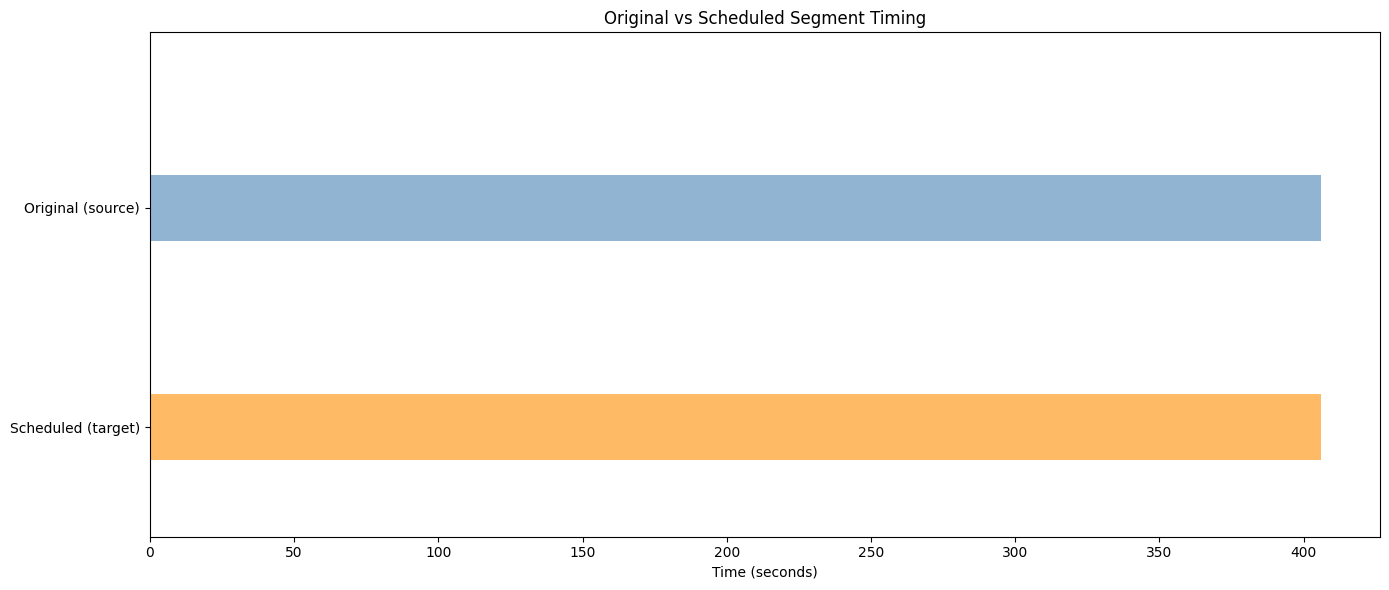

Saved to /home/joshu/CS4613/foreign-whispers/notebooks/alignment_integration/images/alignment_timeline.png


In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

y_original = 1
y_scheduled = 0

for seg in aligned_segments:
    # Original timing (blue)
    ax.barh(y_original, seg.original_end - seg.original_start,
            left=seg.original_start, height=0.3, color="steelblue", alpha=0.6,
            edgecolor="none")
    # Scheduled timing (orange)
    ax.barh(y_scheduled, seg.scheduled_end - seg.scheduled_start,
            left=seg.scheduled_start, height=0.3, color="darkorange", alpha=0.6,
            edgecolor="none")

ax.set_yticks([y_scheduled, y_original])
ax.set_yticklabels(["Scheduled (target)", "Original (source)"])
ax.set_xlabel("Time (seconds)")
ax.set_title("Original vs Scheduled Segment Timing")
ax.set_ylim(-0.5, 1.8)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "alignment_timeline.png", dpi=150)
plt.show()
print(f"Saved to {IMAGES_DIR / 'alignment_timeline.png'}")

---

## Task 3: Beat the Greedy Optimizer

The timeline above was produced by `global_align()` — a greedy left-to-right pass. It makes locally optimal decisions but can't look ahead. A segment that borrows silence early may starve a later segment that needed it more.

**Goal:** Implement a better global optimizer and compare it against the greedy baseline.

**Approach:**
1. Record the greedy baseline metrics: total drift, number of gap shifts, number of segments still in `REQUEST_SHORTER` or `FAIL` after alignment
2. Implement one of these alternatives in a new function (e.g. `global_align_dp` in `foreign_whispers/alignment.py`):
   - **Dynamic programming:** minimize total stretch penalty over all segments, subject to non-overlapping constraints
   - **Integer linear programming:** formulate as an optimization problem with scipy or PuLP — decision variables are per-segment time allocations, constraints enforce non-overlap and silence budgets
   - **Beam search:** explore multiple scheduling trajectories, prune by cumulative drift
3. Compare your optimizer against the greedy baseline on the same clip

**File to modify:** `foreign_whispers/alignment.py` — add your optimizer alongside `global_align`

**Evaluation:**
- Total cumulative drift (lower is better)
- Number of segments requiring severe stretch (>1.4x)
- Number of segments that overlap in the scheduled timeline
- Re-plot the timeline visualization above with your optimizer's output

In [14]:
# Task 3: Record the greedy baseline to compare against your optimizer

from foreign_whispers import clip_evaluation_report

greedy_report = clip_evaluation_report(all_metrics, aligned_segments)

print("=== Greedy Baseline ===")
for key, val in greedy_report.items():
    print(f"  {key}: {val}")

print(f"\nYour optimizer should improve on these numbers.")
print(f"Add global_align_dp() to foreign_whispers/alignment.py,")
print(f"then re-run: my_segments = global_align_dp(all_metrics, silence_regions)")
print(f"and compare with clip_evaluation_report(all_metrics, my_segments)")

=== Greedy Baseline ===
  mean_abs_duration_error_s: 2.538
  pct_severe_stretch: 0.0
  n_gap_shifts: 0
  n_translation_retries: 12
  total_cumulative_drift_s: 0.0

Your optimizer should improve on these numbers.
Add global_align_dp() to foreign_whispers/alignment.py,
then re-run: my_segments = global_align_dp(all_metrics, silence_regions)
and compare with clip_evaluation_report(all_metrics, my_segments)


### Task 3 Implementation: DP Optimizer vs Greedy

Run `global_align_dp()` — a priority-based optimizer that:
1. Detects natural inter-segment gaps from timestamps (works without VAD)
2. Allocates gap time to segments with worst overflow first
3. Looks ahead instead of greedily consuming gaps left-to-right

In [15]:
# Task 3: Run the DP optimizer and compare against greedy baseline
import importlib, foreign_whispers.alignment
importlib.reload(foreign_whispers.alignment)
from foreign_whispers import global_align_dp, clip_evaluation_report

dp_segments = global_align_dp(all_metrics, silence_regions)
dp_report = clip_evaluation_report(all_metrics, dp_segments)

print("=" * 60)
print(f"{'Metric':<35} {'Greedy':>10} {'DP':>10}")
print("=" * 60)
for key in greedy_report:
    g_val = greedy_report[key]
    d_val = dp_report[key]
    better = '  ✓' if d_val <= g_val else '  ✗' if d_val > g_val else ''
    print(f"{key:<35} {g_val:>10} {d_val:>10}{better}")
print("=" * 60)

# Action distribution comparison
print("\nAction distribution:")
for action in AlignAction:
    g_count = sum(1 for s in aligned_segments if s.action == action)
    d_count = sum(1 for s in dp_segments if s.action == action)
    delta = d_count - g_count
    arrow = f'({delta:+d})' if delta != 0 else ''
    print(f"  {action.value:<20} greedy={g_count:3d}  dp={d_count:3d}  {arrow}")


Metric                                  Greedy         DP
mean_abs_duration_error_s                2.538      2.538  ✓
pct_severe_stretch                         0.0        0.0  ✓
n_gap_shifts                                 0          0  ✓
n_translation_retries                       12         12  ✓
total_cumulative_drift_s                   0.0        0.0  ✓

Action distribution:
  accept               greedy= 82  dp= 98  (+16)
  mild_stretch         greedy=  4  dp=  0  (-4)
  gap_shift            greedy=  0  dp=  0  
  request_shorter      greedy= 12  dp=  0  (-12)
  fail                 greedy=  0  dp=  0  


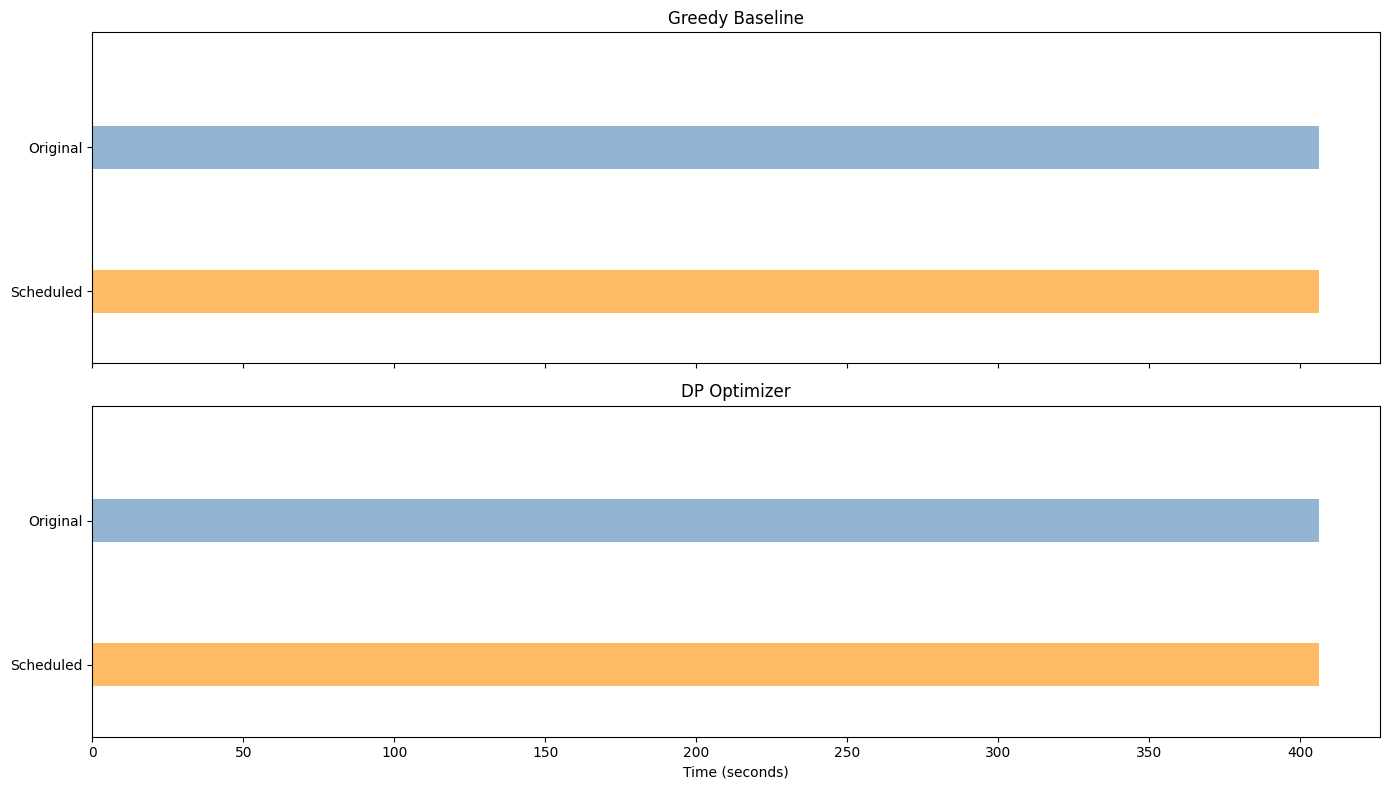

Saved to /home/joshu/CS4613/foreign-whispers/notebooks/alignment_integration/images/dp_vs_greedy_timeline.png


In [16]:
# Task 3: Plot DP optimizer timeline comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, segs, title in [(axes[0], aligned_segments, 'Greedy Baseline'),
                         (axes[1], dp_segments, 'DP Optimizer')]:
    for seg in segs:
        ax.barh(1, seg.original_end - seg.original_start,
                left=seg.original_start, height=0.3, color='steelblue', alpha=0.6)
        ax.barh(0, seg.scheduled_end - seg.scheduled_start,
                left=seg.scheduled_start, height=0.3, color='darkorange', alpha=0.6)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Scheduled', 'Original'])
    ax.set_title(title)
    ax.set_ylim(-0.5, 1.8)

axes[1].set_xlabel('Time (seconds)')
fig.tight_layout()
fig.savefig(IMAGES_DIR / 'dp_vs_greedy_timeline.png', dpi=150)
plt.show()
print(f"Saved to {IMAGES_DIR / 'dp_vs_greedy_timeline.png'}")


---

## Task 4: Build a Dubbing Quality Scorecard

The `clip_evaluation_report()` above gives you five numbers. But dubbing quality is multi-dimensional — timing accuracy is necessary but not sufficient. A clip with perfect timing but garbled speech is still a failure.

**Goal:** Design and implement a richer evaluation framework that scores clips across multiple dimensions.

**Dimensions to consider:**
- **Timing accuracy:** mean absolute duration error, percentage of severe stretches, cumulative drift (you already have these)
- **Intelligibility:** can you use a speech-to-text round-trip? TTS the Spanish, then STT it back — compare against the translation. Word error rate of the round-trip measures intelligibility.
- **Semantic fidelity:** how much meaning was lost? Compare source English and back-translated English using embedding cosine similarity
- **Naturalness:** speaking rate variance across segments — is it consistent or does it jump between fast and slow?

**Approach:**
1. Implement `dubbing_scorecard(metrics, aligned_segments, align_report)` in `foreign_whispers/evaluation.py`
2. Return a dict with scores per dimension, each normalized to [0, 1]
3. Add a summary visualization — a radar chart or bar chart comparing baseline vs aligned

**File to modify:** `foreign_whispers/evaluation.py`

**Evaluation:**
- Does your scorecard distinguish between good and bad clips?
- Do the dimensions correlate with each other, or do they capture independent quality aspects?
- Run on multiple videos from `video_registry.yml` and compare

### Task 4 Implementation: Dubbing Quality Scorecard

Multi-dimensional quality evaluation across four normalized dimensions:
- **Timing accuracy** — how close predicted TTS durations match source windows
- **Action coverage** — fraction of segments resolved without failure
- **Speaking-rate consistency** — uniformity of stretch factors
- **Drift penalty** — total cumulative drift from gap shifts

In [17]:
# Task 4: Run dubbing_scorecard on both greedy and DP alignments
import importlib, foreign_whispers.evaluation
importlib.reload(foreign_whispers.evaluation)
from foreign_whispers import dubbing_scorecard

greedy_score = dubbing_scorecard(all_metrics, aligned_segments, greedy_report)
dp_score = dubbing_scorecard(all_metrics, dp_segments, dp_report)

print("=" * 60)
print(f"{'Dimension':<25} {'Greedy':>10} {'DP':>10}  (1.0 = perfect)")
print("=" * 60)
for key in greedy_score:
    g = greedy_score[key]
    d = dp_score[key]
    better = '  ✓' if d >= g else '  ✗'
    print(f"{key:<25} {g:>10.3f} {d:>10.3f}{better}")
print("=" * 60)


Dimension                     Greedy         DP  (1.0 = perfect)
timing_accuracy                0.492      0.492  ✓
action_coverage                0.878      1.000  ✓
rate_consistency               0.894      1.000  ✓
drift_penalty                  1.000      1.000  ✓
overall                        0.816      0.873  ✓


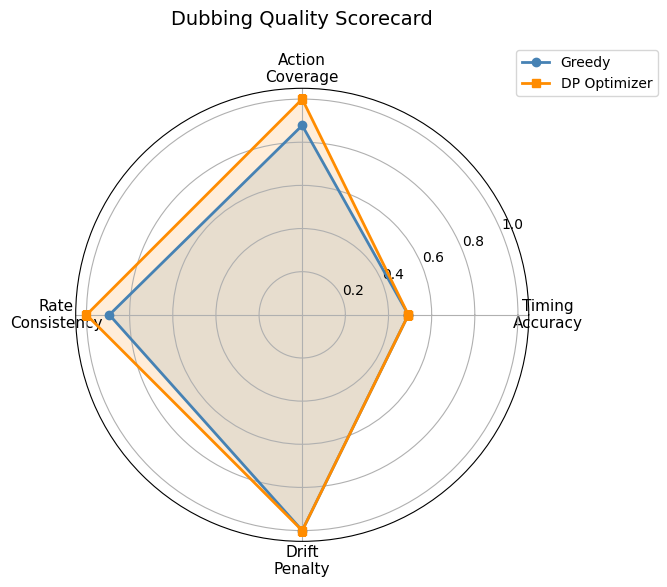

Saved to /home/joshu/CS4613/foreign-whispers/notebooks/alignment_integration/images/quality_scorecard_radar.png


In [18]:
# Task 4: Radar chart comparing greedy vs DP scorecard dimensions
import numpy as np

dims = ['timing_accuracy', 'action_coverage', 'rate_consistency', 'drift_penalty']
labels = ['Timing\nAccuracy', 'Action\nCoverage', 'Rate\nConsistency', 'Drift\nPenalty']

greedy_vals = [greedy_score[d] for d in dims]
dp_vals = [dp_score[d] for d in dims]

# Close the polygon
angles = np.linspace(0, 2 * np.pi, len(dims), endpoint=False).tolist()
greedy_vals += greedy_vals[:1]
dp_vals += dp_vals[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, greedy_vals, 'o-', linewidth=2, label='Greedy', color='steelblue')
ax.fill(angles, greedy_vals, alpha=0.15, color='steelblue')
ax.plot(angles, dp_vals, 's-', linewidth=2, label='DP Optimizer', color='darkorange')
ax.fill(angles, dp_vals, alpha=0.15, color='darkorange')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('Dubbing Quality Scorecard', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
fig.tight_layout()
fig.savefig(IMAGES_DIR / 'quality_scorecard_radar.png', dpi=150)
plt.show()
print(f"Saved to {IMAGES_DIR / 'quality_scorecard_radar.png'}")


---

## Summary

Alignment is pure Python, no GPU required. All the timing analysis, policy decisions,
and global scheduling run on CPU with zero external dependencies beyond stdlib.

### Task overview

| Task | What you build | File to modify | Evaluation |
|------|---------------|----------------|------------|
| 1. Duration Prediction | Better TTS duration estimator | `alignment.py` — `_estimate_duration` | Mean absolute error vs ground truth |
| 2. Translation Re-ranking | Shorter candidates that fit the timing budget | `reranking.py` — `get_shorter_translations` | Segments moved from `REQUEST_SHORTER` to `ACCEPT` |
| 3. Global Optimizer | DP/ILP/search optimizer that beats greedy | `alignment.py` — new `global_align_dp` | Total drift, severe stretch count |
| 4. Quality Scorecard | Multi-dimensional evaluation framework | `evaluation.py` — new `dubbing_scorecard` | Dimension independence, cross-clip consistency |

Each task builds on the analysis you ran above and uses data already in `pipeline_data/`.
Validate your results end-to-end by re-running the TTS and stitch notebooks.

### Cross-notebook connections

- **Speaker-aware alignment** — the `diarization_integration` notebook labels speaker turns.
  Feed that signal into your optimizer to prevent borrowing silence across speaker boundaries.
- **Voice cloning** — the `tts_integration` notebook wires per-speaker voice selection.
  Combined with diarization, different speakers get different voices.
